In [1]:
from narwhals.selectors import categorical

"""
Supervised Learning
 -Classification Task: Logistic Regression
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from class_utils.lab_utils_common import dlc,plot_data,draw_vthresh,sigmoid
from class_utils.plt_one_addpt_onclick import plt_one_addpt_onclick
from class_utils.plt_logistic_loss import plt_logistic_cost,plt_two_logistic_loss_curves,plt_simple_example
from class_utils.plt_logistic_loss import soup_bowl,plt_logistic_squared_error

%matplotlib widget
plt.style.use(r"E:\BongoDev\Classification_Analysis\deeplearning.mplstyle")



In [2]:
DATASET_PATH=r"E:\BongoDev\Classification_Analysis\Data\cancer.csv"
cancer_dataset=pd.read_csv(DATASET_PATH)
cancer_dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84358402,M,20.29,14.34,135.1,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.2,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
4,844359,M,18.25,19.98,119.6,1040.0,0.09463,0.10900,0.1127,0.07400,...,27.66,153.2,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN


In [3]:
cancer_dataset['diagnosis'].value_counts()

diagnosis
B    357
M    116
Name: count, dtype: int64

In [4]:
"""
Classification: Identify the diagnosis given the medical report
"""
cancer_dataset=cancer_dataset[['area_mean','diagnosis']]
cancer_dataset.head()


,area_mean,diagnosis
0,1001.0,M
1,1326.0,M
2,1203.0,M
3,1297.0,M
4,1040.0,M


In [5]:
cancer_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 473 entries, 0 to 472
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area_mean  473 non-null    float64
 1   diagnosis  473 non-null    str    
dtypes: float64(1), str(1)
memory usage: 8.0 KB


In [6]:
numerical_cols=cancer_dataset.select_dtypes(include='number').columns
numerical_cols

Index(['area_mean'], dtype='str')

In [7]:
categorical_cols=cancer_dataset.select_dtypes(include=['object','str']).columns
categorical_cols

Index(['diagnosis'], dtype='str')

In [8]:
cancer_dataset[numerical_cols]

,area_mean
0,1001.0
1,1326.0
2,1203.0
3,1297.0
4,1040.0
...,...
468,1347.0
469,1479.0
470,1261.0
471,1265.0


In [9]:
cancer_dataset[categorical_cols]

,diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
468,M
469,M
470,M
471,M


In [10]:
# Normalization
min=cancer_dataset[numerical_cols].min()
max=cancer_dataset[numerical_cols].max()
print(min,max)

cancer_dataset[numerical_cols]=(cancer_dataset[numerical_cols]-min)/(max-min)
cancer_dataset.head()

area_mean    143.5
dtype: float64 area_mean    2501.0
dtype: float64


,area_mean,diagnosis
0,0.363733,M
1,0.501591,M
2,0.449417,M
3,0.489290,M
4,0.380276,M


In [11]:
# Label Encoding

cancer_dataset[categorical_cols]=cancer_dataset[categorical_cols].apply(
    lambda col:pd.Categorical(col).codes
)
cancer_dataset.head()

,area_mean,diagnosis
0,0.363733,1
1,0.501591,1
2,0.449417,1
3,0.489290,1
4,0.380276,1


In [12]:
print(cancer_dataset['diagnosis'].value_counts())

diagnosis
0    357
1    116
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

train_df,test_df=train_test_split(cancer_dataset,
                                  test_size=0.2,
                                  stratify=cancer_dataset['diagnosis'],
                                  random_state=42)
print(train_df['diagnosis'].value_counts())
print(test_df['diagnosis'].value_counts())


diagnosis
0    285
1     93
Name: count, dtype: int64
diagnosis
0    72
1    23
Name: count, dtype: int64


In [14]:
train_df=pd.concat(
    [
        train_df[train_df['diagnosis']==0].sample(n=93,random_state=42),
        train_df[train_df['diagnosis']==1].sample(n=93,random_state=42)
    ]

)
train_df['diagnosis'].value_counts()

diagnosis
0    93
1    93
Name: count, dtype: int64

In [15]:
X=train_df.drop('diagnosis',axis=1)
y=train_df['diagnosis']

train_X,val_X,train_y,val_y=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

train_X=np.asarray(train_X)
train_y=np.asarray(train_y)
val_X=np.asarray(val_X)
val_y=np.asarray(val_y)

In [16]:
test_X=test_df.drop('diagnosis',axis=1)
test_y=test_df['diagnosis']

test_X=np.asarray(test_X)
test_y=np.asarray(test_y)

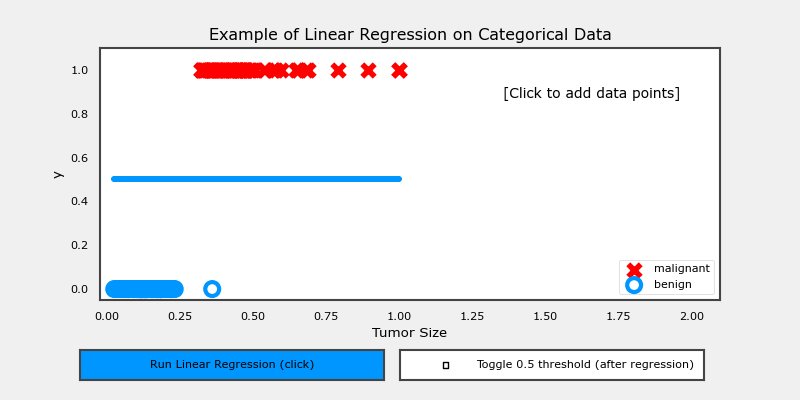

In [42]:
"""
Linear Regression:
y_pred=w*x+b
"""
w=np.zeros(1)
b=0
plt.close('all')
__=plt_one_addpt_onclick(train_X,train_y,w,b,logistic=False)

In [18]:
"""
lOGISTIC REGRESSION
z=wx+b
y=g(z)
g is a sigmoid/logistic function
g(z)=1/(1+e^(-z))
"""

z=np.arange(-10,11)
g=1/(1+np.exp(-z))

print(f"z:{z}\n,g={g}")

z:[-10  -9  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2   3   4   5   6   7
   8   9  10]
,g=[4.54e-05 1.23e-04 3.35e-04 9.11e-04 2.47e-03 6.69e-03 1.80e-02 4.74e-02
 1.19e-01 2.69e-01 5.00e-01 7.31e-01 8.81e-01 9.53e-01 9.82e-01 9.93e-01
 9.98e-01 9.99e-01 1.00e+00 1.00e+00 1.00e+00]


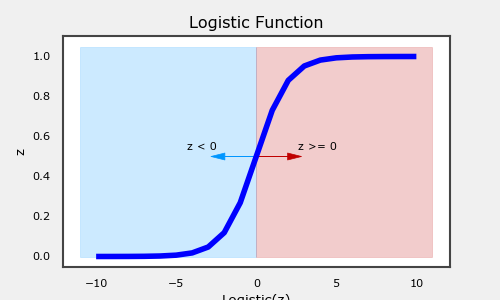

In [19]:
fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.plot(z,g,c='b')

ax.set_title('Logistic Function')
ax.set_xlabel('Logistic(z)')
ax.set_ylabel('z')
draw_vthresh(ax,0)

In [20]:
"""
ML Algorithm : Logistic Regression
"""
def get_cancer_prediction(x,w,b):
    z=w*x+b
    g=1/(1+np.exp(-z))
    return g

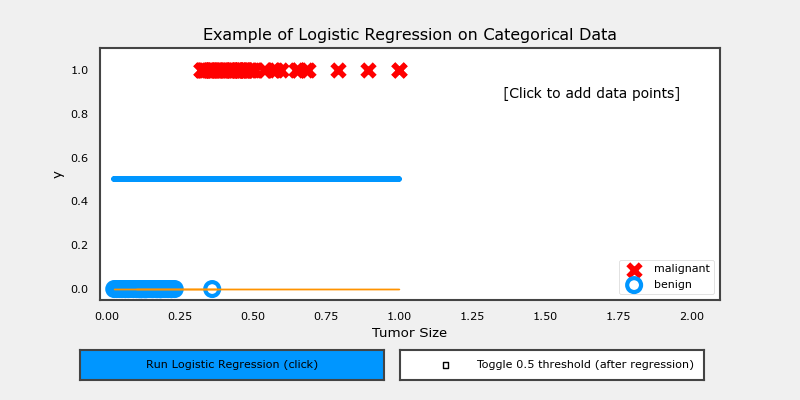

In [44]:
plt.close('all')
__=plt_one_addpt_onclick(train_X,train_y,w,b,logistic=True)

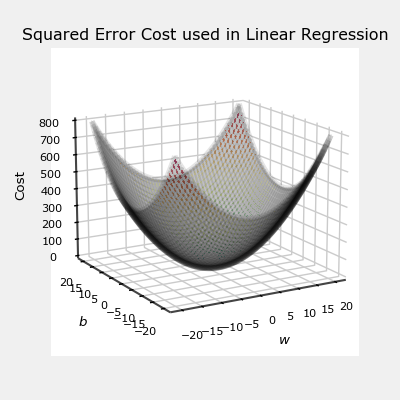

In [45]:
"""
LINEAR REGRESSION COST LOSS
What is concept of selecting cost function for a task?
-Select such a cost function where it is guaranteed that the gradient descent algorithm is able to minimize the cost function
-The 3d cost error should be like this figure below ( the soup bowl sized shape is the ideal condition where there is one minima, thus where the position of a parameter might be , it would be easy to follow downwards to that single minima , thus proper gradient descent is guaranteed
"""


soup_bowl()

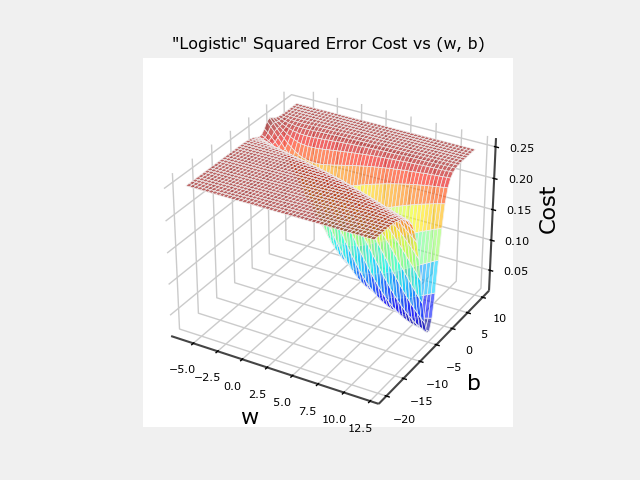

In [47]:
"""
LOGISTIC SQUARED COST LOSS
"""
plt.close('all')
plt_logistic_squared_error(train_X,train_y)
plt.show()

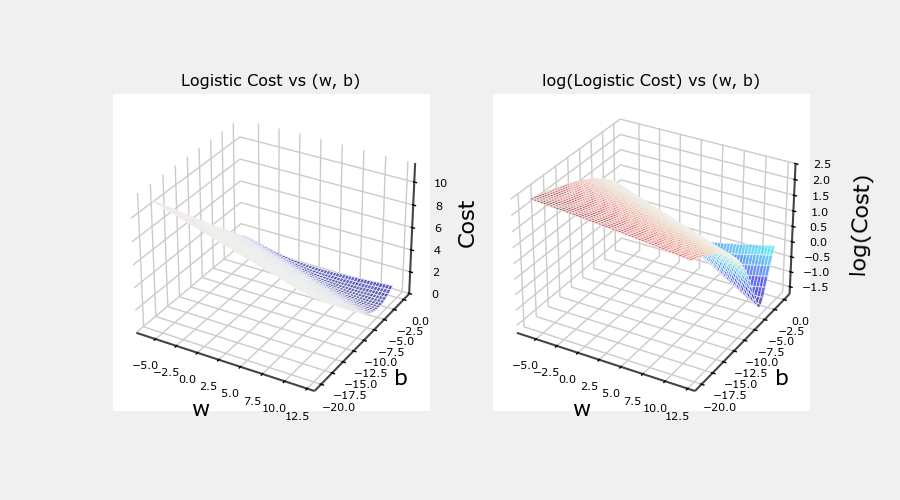

In [24]:
plt.close('all')
cst=plt_logistic_cost(train_X,train_y)

In [25]:
"""
Cost Function : Logistic log loss
"""
def cost_function(X,y,w,b):
    m=X.shape[0]
    cost=0.0
    for i in range(m):
        y_pred=get_cancer_prediction(X[i],w,b)
        log_loss=-y[i]*np.log(y_pred)-(1-y[i])*np.log(1-y_pred)
        cost+=log_loss
    cost=cost/m
    return cost[0]


In [26]:
log_loss=cost_function(train_X,train_y,w,b)
print(f"Log loss is {log_loss}(parameters not learned yet)")

Log loss is 0.6931471805599463(parameters not learned yet)


In [27]:
"""
Gradient Descent
-Compute(Cost) Done
-Compute Gradient
-Update parameters
"""

def compute_gradient(X,y_true,w,b):
    delta = 1e-9
    cost_1=cost_function(X,y_true,w,b)
    cost_2=cost_function(X,y_true,w+delta,b)
    cost_3=cost_function(X,y_true,w,b+delta)

    dw=(cost_2-cost_1)/delta
    db=(cost_3-cost_1)/delta
    return dw,db

In [28]:
THRESHOLD=0.5


def train_model(train_X,train_y,val_X,val_y,lr=0.001,epochs=10000):
    w=np.random.randint(0,10,1)
    b=0
    for epoch in range(epochs):
        dw,db=compute_gradient(train_X,train_y,w,b)

        w=w-lr*dw
        b=b-lr*db

        if epoch%1000==0:
            loss=cost_function(train_X,train_y,w,b)
            val_loss=cost_function(val_X,val_y,w,b)
            print(f"Epoch: {epoch}/{epochs},loss:{loss:.3f},val_loss:{val_loss:.3f}")
    return w,b

w,b=train_model(train_X,train_y,val_X,val_y)
print("Weight:",w,"Bias:",b)

Epoch: 0/10000,loss:0.608,val_loss:0.604
Epoch: 1000/10000,loss:0.540,val_loss:0.536
Epoch: 2000/10000,loss:0.491,val_loss:0.488
Epoch: 3000/10000,loss:0.458,val_loss:0.455
Epoch: 4000/10000,loss:0.436,val_loss:0.433
Epoch: 5000/10000,loss:0.420,val_loss:0.418
Epoch: 6000/10000,loss:0.410,val_loss:0.408
Epoch: 7000/10000,loss:0.402,val_loss:0.401
Epoch: 8000/10000,loss:0.397,val_loss:0.396
Epoch: 9000/10000,loss:0.393,val_loss:0.392
Weight: [5.09] Bias: -1.2926767068432987


In [29]:
test_loss=cost_function(test_X,test_y,w,b)
print(f"Log_Loss is {test_loss}")

Log_Loss is 0.41560038797178195


In [39]:
"""
Evaluation Metric: Accuracy
"""
y_pred_train=get_cancer_prediction(train_X,w,b)
y_pred_train=np.where(y_pred_train>=THRESHOLD,1,0)

train_acc=0
for i in range(len(y_pred_train)):
    if y_pred_train[i]==train_y[i]:
        train_acc+=1
train_acc=train_acc/len(y_pred_train) * 100.0

y_pred_test=get_cancer_prediction(test_X,w,b)
y_pred_test=np.where(y_pred_test>=THRESHOLD,1,0)

test_acc=0
for i in range(len(y_pred_test)):
    if y_pred_test[i]==test_y[i]:
        test_acc+=1
test_acc=test_acc/len(y_pred_test) * 100.0

print(f"Train accuracy: {train_acc:0.2f}%")
print(f"test accuracy: {test_acc:0.2f}%")

Train accuracy: 99.32%
test accuracy: 98.95%


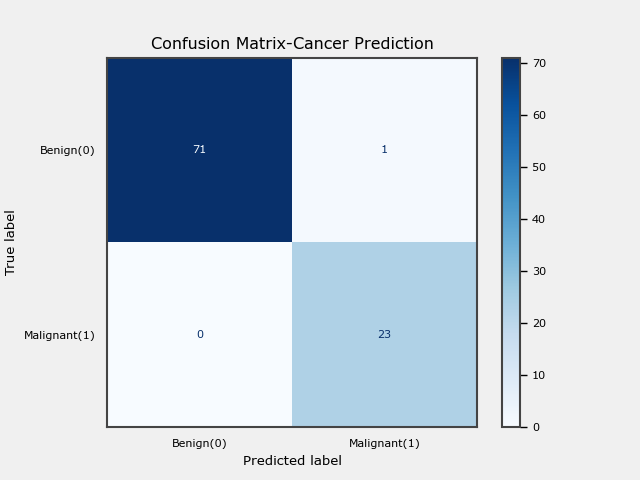

Confusion Matrix
[[71  1]
 [ 0 23]]

TN | FP
-------
FN | TP


In [40]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_prob=get_cancer_prediction(test_X,w,b)
y_pred=np.where(y_pred_prob>=THRESHOLD,1,0)

cm=confusion_matrix(test_y,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Benign(0)','Malignant(1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix-Cancer Prediction')
plt.show()


print("Confusion Matrix")
print(cm)
print("\nTN | FP")
print("-------")
print("FN | TP")